STARTING S&P 500 DUAL-TRIGGER STAT-ARB ENGINE (NO-MU NOISE + CONSECUTIVE LOSS GATE)

[Pre-Processing] Constructing Volatility Contexts...

[Screening Pass @ 2024-09-09 | Progress:   0.2% (1/500)] SciPy C-Accelerated Search...

[Dynamic Rebalance @ 2024-09-09 | Progress:   0.2% (1/500)] Cause: INITIAL_ENTRY | Vol Ratio: 1.13 | VIX: 15.6
  --> Pipeline Funnel : Ghost=13 | Eligible=0 | Live=0
------------------------------------------------------------
[State Engine] Pipeline checkpoint successfully saved to 'artifacts/model_A_1_5_1/stat_arb_state_20260907_100725.pkl'.

[Dynamic Rebalance @ 2024-09-10 | Progress:   0.4% (2/500)] Cause: SIGNAL_ENTRY | Vol Ratio: 1.19 | VIX: 16.6
  --> Pipeline Funnel : Ghost=14 | Eligible=3 | Live=3
  --> SLSQP Metrics   : Eff Gross=0.68 | Port Vol=0.0841 | Turnover Drag=0.000541
  --> Top Allocations :
      PAYX/SWK | W_A: -25.0% | W_B: 11.7% | Inno Z (e_t): 2.61 | LinUCB Gate: 1.85σ
      CMS/EIX | W_A: -25.0% | W_B: 19.2% | Inno Z (e_t): 2.16 | LinUCB 

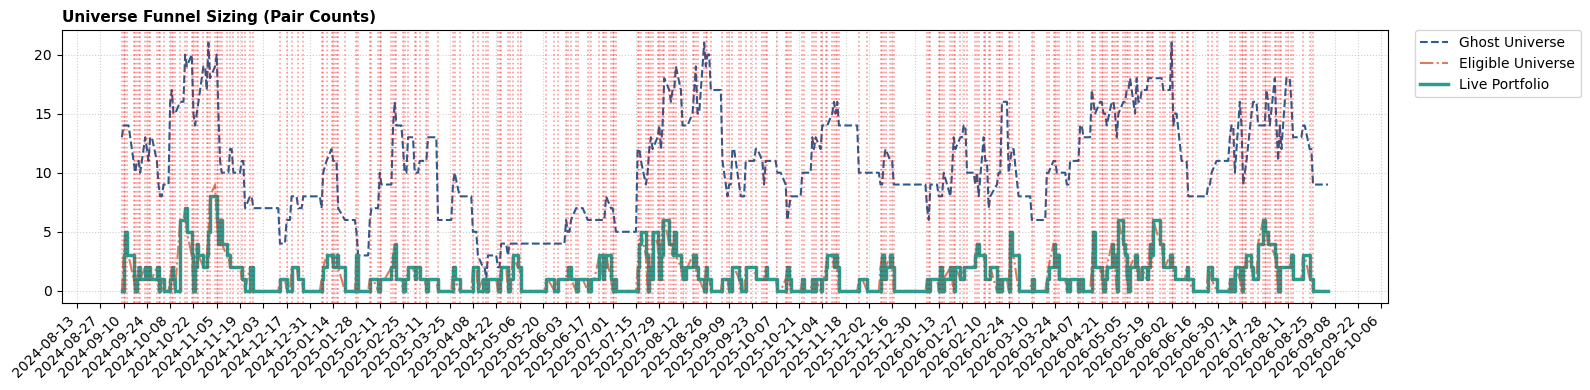

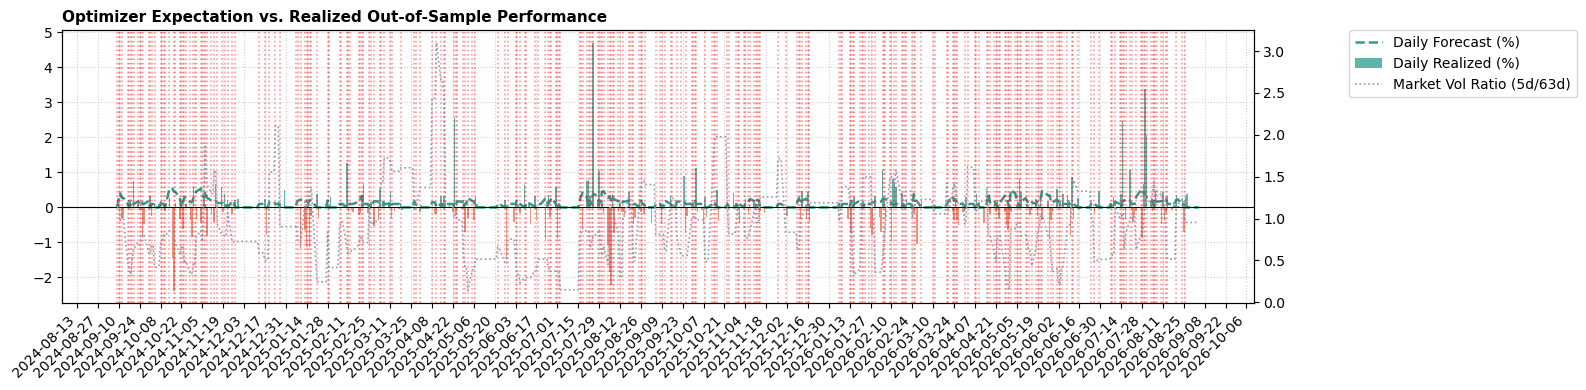

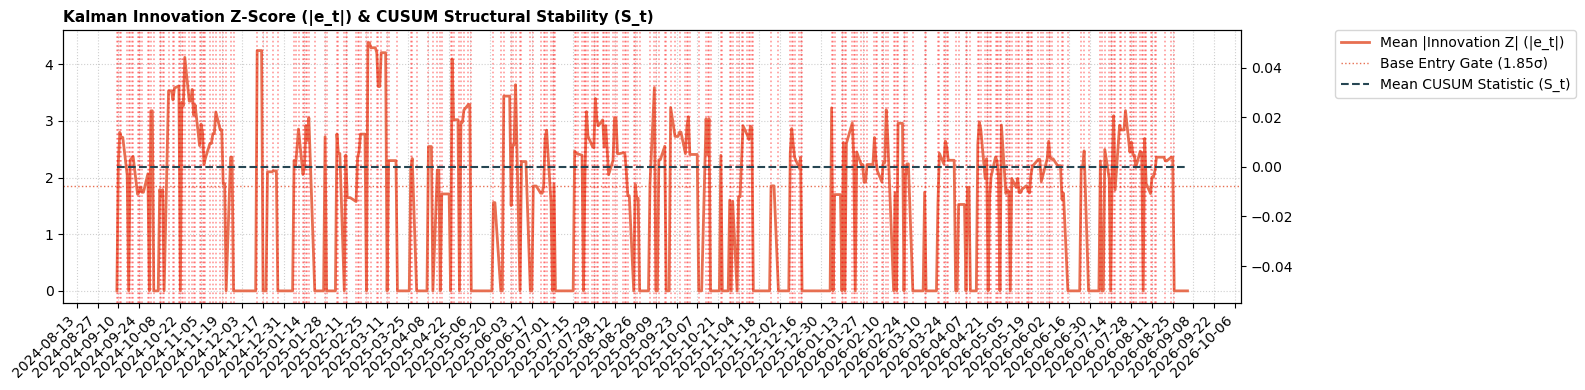

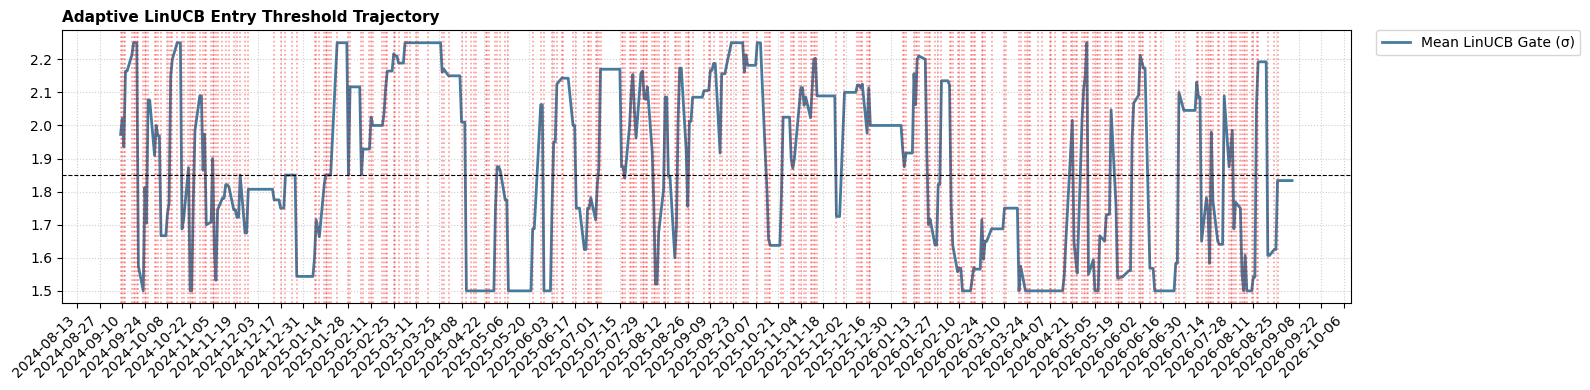

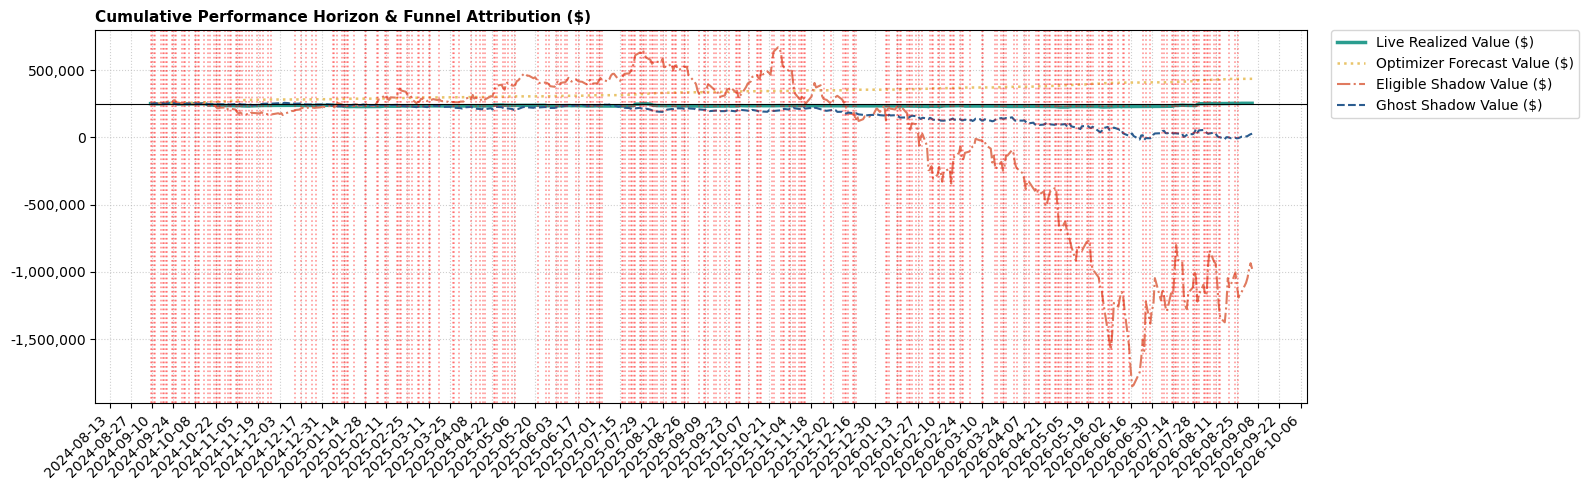

In [2]:
# ==============================================================================
# S&P 500 STAT-ARB PIPELINE: FULL FUNNEL SHADOW TRACKING ENGINE
# ==============================================================================

import os
import gc
import pickle
import warnings
from typing import Dict, List, Tuple, Optional
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import chi2, t as student_t
from scipy.spatial.distance import cdist
from scipy.optimize import minimize as scipy_minimize
import vectorbt as vbt

from joblib import Parallel, delayed
from mabwiser.mab import MAB, LearningPolicy

warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 250)

from datetime import datetime

# Evaluated ONCE at script startup
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_id = "model_A_1_5_1"

# ==============================================================================
# 1. INSTITUTIONAL PARAMETER CONFIGURATION
# ==============================================================================
run_params = {
    "price_csv": "data/universe_daily_train.csv",
    "oos_price_csv": "data/universe_daily_val.csv",
    "constituents_path": "data/constituents.csv",
    "state_persistence_file": f"artifacts/{model_id}/stat_arb_state_{timestamp}.pkl",

    # LOOKBACK & WINDOW SIZES
    "lookback_days": 504,             
    "min_history_days": 100,          
    "rolling_window_days": 252,       
    
    # DYNAMIC DUAL-TRIGGER PARAMETERS
    "weight_drift_threshold": 0.05,     # 5% max weight drift gate (||w_t - w*||_inf > 0.05)
    "screening_freq_days": 20,          # Periodic universe cointegration refresh
    "cooldown_days": 15,              
    
    # KALMAN & HURST PARAMETERS
    "kalman_delta": 1e-4,              
    "kalman_obs_noise": 1e-3,          
    "kalman_z_window": 21,             
    "max_hurst_exponent": 0.52,        
    
    # DE-CHOKED SCREENING GATEWAYS
    "min_correlation": 0.45,          
    "p_value_threshold": 0.10,         
    "mp_window": 21,                   
    "max_mp_distance": 4.50,           
    
    "min_half_life": 3.0,             
    "max_half_life": 30.0,            
    "tau_hl_penalty": 5.0,             
    
    "base_min_z_spread": 1.85,         
    "exit_z_spread": 0.20,            
    "stop_loss_z": 2.75,               
    "bocpd_cp_threshold": 0.35,        
    
    "ghost_eval_window_days": 63,     
    "max_half_life_expansion_ratio": 2.5,
    "jump_lookback_days": 15,          
    "jump_threshold": 4.0,             
    "max_macro_correlation": 0.20,    
    
    "demote_bottom_n": 0,              
    "promote_top_n": 20,              
    
    # RISK & FACTOR BOUNDS
    "obj_alpha_return": 1.0,          
    "obj_beta_risk": 0.5,             
    "max_factor_exposure": 0.10,       
    "max_gross_exposure": 1.8,        
    "max_pairs_in_book": 12,          
    "max_pairs_per_sector": 3,        
    "max_sleeve_weight": 0.25,        
    "max_asset_cap": 0.15,             

    # MICROSTRUCTURE & EXECUTION
    "max_adv_participation": 0.015,    
    "initial_capital": 250_000.0,
    "exec_fee": 0.00015,              
    "borrow_bps": 50.0
}

# ==============================================================================
# 2. STATE PERSISTENCE ENGINE (WITH SAFE DIRECTORY CREATION)
# ==============================================================================
class StatePersistenceEngine:
    """Handles serialization of live Kalman states, LinUCB models, and cooldown registries."""
    @staticmethod
    def save_checkpoint(filepath: str, state_dict: dict):
        try:
            os.makedirs(os.path.dirname(filepath), exist_ok=True)
            with open(filepath, "wb") as f:
                pickle.dump(state_dict, f)
            print(f"[State Engine] Pipeline checkpoint successfully saved to '{filepath}'.", flush=True)
        except Exception as e:
            print(f"[State Engine Error] Failed to save checkpoint: {str(e)}", flush=True)

    @staticmethod
    def load_checkpoint(filepath: str) -> Optional[dict]:
        if not os.path.exists(filepath):
            return None
        try:
            with open(filepath, "rb") as f:
                state_dict = pickle.load(f)
            print(f"[State Engine] Loaded existing pipeline checkpoint from '{filepath}'.", flush=True)
            return state_dict
        except Exception as e:
            print(f"[State Engine Error] Failed to load checkpoint: {str(e)}", flush=True)
            return None

# ==============================================================================
# 3. CLOSED-FORM MATHEMATICAL UTILITIES
# ==============================================================================
def calculate_half_life_fast(spread: np.ndarray) -> float:
    if len(spread) < 30: return 25.0
    s_lag = spread[:-1]
    s_diff = spread[1:] - s_lag
    x_dev = s_lag - np.mean(s_lag)
    y_dev = s_diff - np.mean(s_diff)
    var_x = np.sum(x_dev**2)
    if var_x < 1e-12: return 25.0
    gamma = np.sum(x_dev * y_dev) / var_x
    if gamma <= -1.0: return 1.0
    if gamma >= 0.0: return np.inf
    return float(-0.6931471805599453 / np.log(1.0 + gamma))

def compute_hurst_exponent_fast(time_series: np.ndarray, max_lag: int = 20) -> float:
    N = len(time_series)
    if N < max_lag * 2: return 0.50
    lags = np.arange(2, max_lag)
    tau = np.empty(len(lags), dtype=np.float64)
    for idx, lag in enumerate(lags):
        tau[idx] = np.std(time_series[lag:] - time_series[:-lag])
    log_lags = np.log(lags)
    log_tau = np.log(np.maximum(tau, 1e-8))
    x_dev = log_lags - np.mean(log_lags)
    y_dev = log_tau - np.mean(log_tau)
    slope = np.sum(x_dev * y_dev) / np.sum(x_dev**2)
    return float(slope * 2.0)

def compute_sortino_ratio(returns: pd.Series, target_return: float = 0.0) -> float:
    if len(returns) < 5 or returns.std() < 1e-8:
        return 0.0
    mean_ret = returns.mean() * 252.0
    downside_rets = returns[returns < target_return]
    downside_std = np.sqrt(np.mean(downside_rets**2)) * np.sqrt(252.0) if len(downside_rets) > 0 else 1e-6
    return float(mean_ret / max(downside_std, 1e-6))

def compute_linucb_continuous_reward(entry_z: float, exit_z: float, days_held: float, half_life: float, exit_reason: str) -> float:
    abs_entry = max(0.1, abs(entry_z))
    abs_exit = abs(exit_z)
    z_capture_efficiency = (abs_entry - abs_exit) / abs_entry
    hl_ratio = days_held / max(1.0, half_life)
    duration_factor = np.exp(-0.30 * max(0.0, hl_ratio - 1.0))

    if exit_reason == "target_exit":
        reward = 2.0 * max(0.1, z_capture_efficiency) * duration_factor
    elif exit_reason == "stop_loss":
        reward = -1.5 * (abs_exit / abs_entry)
    elif exit_reason == "structural_break":
        reward = -2.0
    else:
        reward = -0.4 * min(2.0, hl_ratio)

    return float(np.clip(reward, -2.0, 2.0))

# ==============================================================================
# 4. FAST NUMPY KALMAN & BOCPD ENGINES
# ==============================================================================
class FastKalmanFilter:
    def __init__(self, delta: float = 1e-4, obs_noise: float = 1e-3, z_window: int = 21):
        self.delta = delta
        self.obs_noise = obs_noise
        self.z_window = z_window
        self.Q = (delta / (1.0 - delta)) * np.eye(2, dtype=np.float64)

    def filter_series(self, y: np.ndarray, x: np.ndarray) -> Dict[str, np.ndarray]:
        N = len(y)
        state_mean = np.zeros(2, dtype=np.float64)
        state_cov = np.eye(2, dtype=np.float64)
        betas = np.empty(N, dtype=np.float64)
        alphas = np.empty(N, dtype=np.float64)
        v_arr = np.empty(N, dtype=np.float64)
        H = np.ones((2, 1), dtype=np.float64)
        
        for t in range(N):
            H[1, 0] = x[t]
            H_T = H.T
            pred_cov = state_cov + self.Q
            y_hat = (H_T @ state_mean).item()
            v = y[t] - y_hat
            F = (H_T @ pred_cov @ H).item() + self.obs_noise
            K = (pred_cov @ H) / F
            state_mean = state_mean + (K.flatten() * v)
            state_cov = (np.eye(2) - K @ H_T) @ pred_cov
            alphas[t], betas[t], v_arr[t] = state_mean[0], state_mean[1], v

        v_series = pd.Series(v_arr)
        F_emp = v_series.rolling(window=self.z_window, min_periods=5).std().bfill().values**2
        F_emp = np.maximum(F_emp, 1e-4)
        e_t = v_arr / np.sqrt(F_emp)

        return {
            "Beta": betas, "Alpha": alphas, "Innovation": v_arr,
            "Innovation_Var": F_emp, "Innovation_Z": e_t,
            "Final_State_Mean": state_mean, "Final_State_Cov": state_cov
        }

    def step_update(self, state_mean: np.ndarray, state_cov: np.ndarray, y_val: float, x_val: float) -> Tuple[np.ndarray, np.ndarray, float, float]:
        H = np.array([1.0, x_val], dtype=np.float64)
        pred_cov = state_cov + self.Q
        y_hat = (H @ state_mean).item()
        v_t = y_val - y_hat
        F_t = (H @ pred_cov @ H.T).item() + self.obs_noise
        K = (pred_cov @ H) / F_t
        new_mean = state_mean + K * v_t
        new_cov = (np.eye(2) - np.outer(K, H)) @ pred_cov
        return new_mean, new_cov, v_t, F_t

class FastBOCPDEngine:
    def __init__(self, hazard_rate: float = 1.0 / 200.0, alpha0: float = 1.0, beta0: float = 1.0, mu0: float = 0.0, kappa0: float = 1.0, max_K: int = 64):
        self.H = hazard_rate
        self.alpha0, self.beta0, self.mu0, self.kappa0 = alpha0, beta0, mu0, kappa0
        self.max_K = max_K
        self.R_buf = np.zeros((max_K + 1, max_K + 1), dtype=np.float64)
        self.mu_buf = np.zeros(max_K + 1, dtype=np.float64)
        self.kappa_buf = np.zeros(max_K + 1, dtype=np.float64)
        self.alpha_buf = np.zeros(max_K + 1, dtype=np.float64)
        self.beta_buf = np.zeros(max_K + 1, dtype=np.float64)

    def eval_change_point_prob(self, innovations: np.ndarray) -> float:
        T_len = min(len(innovations), self.max_K)
        if T_len < 5: return 0.0
        self.R_buf.fill(0.0)
        self.R_buf[0, 0] = 1.0
        self.mu_buf[0], self.kappa_buf[0], self.alpha_buf[0], self.beta_buf[0] = self.mu0, self.kappa0, self.alpha0, self.beta0
        curr_len = 1

        for t in range(T_len):
            x = innovations[t]
            df = 2.0 * self.alpha_buf[:curr_len]
            scale = np.sqrt(self.beta_buf[:curr_len] * (self.kappa_buf[:curr_len] + 1.0) / (self.alpha_buf[:curr_len] * self.kappa_buf[:curr_len]))
            pred_probs = student_t.pdf(x, df=df, loc=self.mu_buf[:curr_len], scale=scale)
            pred_probs = np.nan_to_num(pred_probs, nan=1e-10)

            self.R_buf[1:curr_len + 1, t + 1] = self.R_buf[0:curr_len, t] * pred_probs * (1.0 - self.H)
            self.R_buf[0, t + 1] = np.sum(self.R_buf[0:curr_len, t] * pred_probs * self.H)
            sum_r = np.sum(self.R_buf[:curr_len + 1, t + 1])
            if sum_r > 0: self.R_buf[:curr_len + 1, t + 1] /= sum_r

            new_mu = (self.kappa_buf[:curr_len] * self.mu_buf[:curr_len] + x) / (self.kappa_buf[:curr_len] + 1.0)
            new_kappa = self.kappa_buf[:curr_len] + 1.0
            new_alpha = self.alpha_buf[:curr_len] + 0.5
            new_beta = self.beta_buf[:curr_len] + (self.kappa_buf[:curr_len] * (x - self.mu_buf[:curr_len])**2) / (2.0 * (self.kappa_buf[:curr_len] + 1.0))

            self.mu_buf[0], self.mu_buf[1:curr_len + 1] = self.mu0, new_mu
            self.kappa_buf[0], self.kappa_buf[1:curr_len + 1] = self.kappa0, new_kappa
            self.alpha_buf[0], self.alpha_buf[1:curr_len + 1] = self.alpha0, new_alpha
            self.beta_buf[0], self.beta_buf[1:curr_len + 1] = self.beta0, new_beta
            curr_len += 1

        return float(self.R_buf[0, T_len])

# ==============================================================================
# 5. LINUCB BANDIT & UNIVERSE SCREENER ENGINES
# ==============================================================================
class LinUCBContextEngine:
    def __init__(self, alpha: float = 1.0):
        self.arms = [1.50, 1.85, 2.25]
        self.mab = MAB(arms=self.arms, learning_policy=LearningPolicy.LinUCB(alpha=alpha))
        warmup_contexts = np.random.randn(15, 4)
        warmup_decisions = np.random.choice(self.arms, size=15)
        warmup_rewards = np.zeros(15)
        self.mab.fit(decisions=warmup_decisions, rewards=warmup_rewards, contexts=warmup_contexts)

    def predict_z_threshold(self, context_vector: np.ndarray) -> float:
        ctx_df = pd.DataFrame([context_vector])
        predicted_arm = self.mab.predict(contexts=ctx_df)
        return float(predicted_arm[0] if isinstance(predicted_arm, (list, np.ndarray)) else predicted_arm)

    def update_policy(self, decisions: List[float], rewards: List[float], contexts: List[np.ndarray]):
        if decisions and rewards and contexts:
            ctx_df = pd.DataFrame(contexts)
            self.mab.partial_fit(decisions=decisions, rewards=rewards, contexts=ctx_df)

class UniverseScreener:
    def __init__(self, constituents_path: str):
        self.constituents_path = constituents_path

    def get_sectors(self, tickers: List[str]) -> pd.Series:
        if os.path.exists(self.constituents_path):
            const = pd.read_csv(self.constituents_path)
            sec_col = "GICS Sector" if "GICS Sector" in const.columns else "Sector"
            sym_col = "Symbol" if "Symbol" in const.columns else "Ticker"
            sector_map = dict(zip(const[sym_col], const[sec_col]))
            return pd.Series(tickers, index=tickers).map(sector_map).fillna("Unknown")
        return pd.Series("Unknown", index=tickers)

# ==============================================================================
# 6. FAST PAIR COINTEGRATION ENGINE (OPTIMIZED SCREENER)
# ==============================================================================
class PairCointegrationEngine:
    def __init__(self, params: dict):
        self.params = params
        self.p_value_threshold = params.get("p_value_threshold", 0.10)
        self.mp_window = params.get("mp_window", 21)
        self.max_mp_distance = params.get("max_mp_distance", 4.50)
        self.max_hurst = params.get("max_hurst_exponent", 0.52)
        self.max_fractional_d = params.get("max_fractional_d", 0.45)
        self.min_half_life = params.get("min_half_life", 3.0)
        self.max_half_life = params.get("max_half_life", 30.0)
        self.tau_hl_penalty = params.get("tau_hl_penalty", 5.0)
        self.exit_z_spread = params.get("exit_z_spread", 0.20)
        self.stop_loss_z = params.get("stop_loss_z", 2.75)
        self.min_history = params.get("min_history_days", 100)
        self.ghost_win = params.get("ghost_eval_window_days", 63)
        self.jump_lookback = params.get("jump_lookback_days", 15)
        self.jump_thresh = params.get("jump_threshold", 4.0)
        self.max_macro_corr = params.get("max_macro_correlation", 0.20)
        self.rebalance_freq = params.get("rebalance_freq_days", 5)
        self.bocpd_cp_threshold = params.get("bocpd_cp_threshold", 0.35)
        
        self.kalman_engine = FastKalmanFilter(
            delta=params.get("kalman_delta", 1e-4),
            obs_noise=params.get("kalman_obs_noise", 1e-3),
            z_window=params.get("kalman_z_window", 21)
        )
        self.bocpd_engine = FastBOCPDEngine()

    @staticmethod
    def estimate_fractional_d_gph(series: np.ndarray, bandwidth_power: float = 0.5) -> float:
        N = len(series)
        if N < 64: return 0.50
        x = series - np.mean(series)
        fft_vals = np.fft.rfft(x)
        periodogram = (np.abs(fft_vals)**2) / (2.0 * np.pi * N)
        m = int(np.floor(N**bandwidth_power))
        if m < 4: return 0.50
        frequencies = 2.0 * np.pi * np.arange(1, m + 1) / N
        periodogram_m = periodogram[1:m + 1]
        X_reg = np.log(4.0 * (np.sin(frequencies / 2.0)**2))
        Y_reg = np.log(np.maximum(periodogram_m, 1e-12))
        x_dev = X_reg - np.mean(X_reg)
        y_dev = Y_reg - np.mean(Y_reg)
        denom = np.sum(x_dev**2)
        if denom < 1e-12: return 0.50
        slope = np.sum(x_dev * y_dev) / denom
        return float(np.clip(-slope, -0.5, 1.0))

    @staticmethod
    def _compute_sliding_ab_distance(p1: np.ndarray, p2: np.ndarray, m: int = 21) -> float:
        if len(p1) < m or len(p2) < m: return 999.0
        v1 = np.lib.stride_tricks.sliding_window_view(p1, window_shape=m)
        v2 = np.lib.stride_tricks.sliding_window_view(p2, window_shape=m)
        v1_std = np.std(v1, axis=1, keepdims=True)
        v1_std[v1_std == 0] = 1e-8
        v1_norm = (v1 - np.mean(v1, axis=1, keepdims=True)) / v1_std
        v2_std = np.std(v2, axis=1, keepdims=True)
        v2_std[v2_std == 0] = 1e-8
        v2_norm = (v2 - np.mean(v2, axis=1, keepdims=True)) / v2_std
        d_matrix = cdist(v1_norm, v2_norm, metric='euclidean')
        return float(np.mean(np.min(d_matrix, axis=1)))

    def _screen_single_pair_fast(self, t1: str, t2: str, p1: np.ndarray, p2: np.ndarray) -> Optional[Tuple[str, str]]:
        valid_mask = ~np.isnan(p1) & ~np.isnan(p2)
        if np.sum(valid_mask) < self.min_history: return None
        
        p1_clean = p1[valid_mask]
        p2_clean = p2[valid_mask]
        
        mean_motif_dist = self._compute_sliding_ab_distance(p1_clean, p2_clean, m=self.mp_window)
        if mean_motif_dist > self.max_mp_distance:
            return None
            
        _, pval, _ = coint(p1_clean, p2_clean)
        if pval <= self.p_value_threshold:
            return (t1, t2)
            
        return None

    def screen_universe_cointegration(self, price_df: pd.DataFrame, sectors: pd.Series, parallel) -> List[Tuple[str, str]]:
        valid_df = price_df.ffill().dropna(axis=1)
        valid_tickers = np.array(valid_df.columns.tolist())
        
        log_prices = np.log(valid_df.values)
        returns_mat = np.diff(log_prices, axis=0)
        corr_matrix = np.corrcoef(returns_mat, rowvar=False)
        var_vec = np.var(log_prices, axis=0)
        var_ratio_matrix = var_vec[:, None] / (var_vec[None, :] + 1e-8)

        sector_arr = sectors.reindex(valid_tickers).values
        sector_match = sector_arr[:, None] == sector_arr[None, :]
        
        triu_mask = np.triu(np.ones_like(sector_match, dtype=bool), k=1)
        
        valid_pairs_mask = (
            triu_mask & 
            sector_match & 
            (corr_matrix >= self.params.get("min_correlation", 0.45)) & 
            (var_ratio_matrix >= 0.20) & 
            (var_ratio_matrix <= 5.0)
        )
        
        i_idx, j_idx = np.where(valid_pairs_mask)
        
        candidates = []
        for i, j in zip(i_idx, j_idx):
            candidates.append((
                valid_tickers[i], 
                valid_tickers[j], 
                log_prices[:, i], 
                log_prices[:, j]
            ))

        results = parallel(
            delayed(self._screen_single_pair_fast)(t1, t2, p1, p2) 
            for t1, t2, p1, p2 in candidates
        )
        return [r for r in results if r is not None]

    def _test_pair(self, t1: str, t2: str, price_df: pd.DataFrame, market_ret: pd.Series, vix_level: float, vol_ratio: float, mab_engine, active_data: dict = None) -> Optional[Dict]:
        s1, s2 = price_df[t1].dropna(), price_df[t2].dropna()
        idx = s1.index.intersection(s2.index)
        if len(idx) < self.min_history: return None

        is_active = active_data is not None
        p1, p2 = np.log(s1.loc[idx].values), np.log(s2.loc[idx].values)
        kf_out = self.kalman_engine.filter_series(p1, p2)
        
        beta_current = float(kf_out["Beta"][-1])
        e_t_current = float(kf_out["Innovation_Z"][-1])
        F_current = float(kf_out["Innovation_Var"][-1])
        static_spread = p1 - (beta_current * p2)
        
        hurst_val = compute_hurst_exponent_fast(static_spread[-126:])
        fractional_d = self.estimate_fractional_d_gph(static_spread[-252:])
        is_fractional_stationary = (0.0 <= fractional_d < self.max_fractional_d)

        if not is_active and (hurst_val >= self.max_hurst and not is_fractional_stationary):
            return None

        K = self.kalman_engine.z_window
        v_sq_F = (kf_out["Innovation"]**2) / kf_out["Innovation_Var"]
        S_t = float(np.sum(v_sq_F[-K:])) if len(v_sq_F) >= K else 0.0
        chi2_crit = chi2.ppf(0.99, df=K)
        
        recent_v = kf_out["Innovation"][-K:]
        lb_pval = acorr_ljungbox(recent_v, lags=[5], return_df=True)['lb_pvalue'].iloc[0] if len(recent_v) > 10 else 1.0
        bocpd_p_reset = self.bocpd_engine.eval_change_point_prob(recent_v)

        is_structural_break = (S_t > chi2_crit) or (lb_pval < 0.05) or (bocpd_p_reset > self.bocpd_cp_threshold)
        
        spread_returns = pd.Series(static_spread).diff().fillna(0).values[-self.ghost_win:]
        if not is_active:
            mkt_r = market_ret.iloc[-len(spread_returns):].values
            if len(mkt_r) > 10 and np.std(spread_returns) > 1e-8 and np.std(mkt_r) > 1e-8:
                corr = np.corrcoef(spread_returns, mkt_r)[0, 1]
                if abs(corr) > self.max_macro_corr:
                    return None

        raw_hl = calculate_half_life_fast(static_spread)
        current_half_life = float(np.clip(raw_hl if not np.isinf(raw_hl) else 25.0, self.min_half_life, self.max_half_life))
        entry_half_life = active_data.get("Entry_Half_Life", current_half_life) if is_active else current_half_life

        if not is_active and (current_half_life < self.min_half_life or current_half_life >= self.max_half_life or is_structural_break): 
            return None

        context_vector = np.array([vol_ratio, vix_level, S_t, current_half_life])
        assigned_min_z = mab_engine.predict_z_threshold(context_vector) if not is_active else active_data.get("Assigned_Min_Z", 1.85)

        days_held = active_data.get("Days_Held", 0) + self.rebalance_freq if is_active else 0
        entry_z = active_data["Entry_Z"] if is_active else e_t_current

        target_reversion_e = max(0.0, abs(e_t_current) - self.exit_z_spread)
        expected_bps_yield = target_reversion_e * np.sqrt(F_current)
        annualization_factor = 252.0 / max(1.0, current_half_life)
        hl_penalty_factor = 1.0 - np.exp(-current_half_life / self.tau_hl_penalty)
        projected_annual_return = expected_bps_yield * annualization_factor * hl_penalty_factor

        return {
            "Asset_A": t1, "Asset_B": t2, 
            "Beta": beta_current, "Half_Life_Days": current_half_life, "Entry_Half_Life": entry_half_life,
            "Z_Spread": e_t_current, "Innovation_Z": e_t_current, "CUSUM_S_t": S_t, "BOCPD_P_Reset": bocpd_p_reset,
            "Expected_Annual_Return": projected_annual_return, "Assigned_Min_Z": assigned_min_z, "Context_Vector": context_vector,
            "Spread_Vol": np.sqrt(F_current), "Days_Held": days_held,
            "Is_Active": is_active, "Entry_Z": entry_z,
            "Ghost_Returns": spread_returns,
            "State_Mean": kf_out["Final_State_Mean"],
            "State_Cov": kf_out["Final_State_Cov"],
            "Recent_V_Buffer": deque(recent_v, maxlen=K)
        }

    def find_pairs(self, price_df: pd.DataFrame, market_ret: pd.Series, sectors: pd.Series, active_pairs: dict, cached_candidate_keys: List[Tuple[str, str]], vix_level: float, vol_ratio: float, mab_engine, parallel) -> pd.DataFrame:
        pairs_to_test = []
        seen = set()

        for p_key, act_data in active_pairs.items():
            pairs_to_test.append((p_key[0], p_key[1], act_data))
            seen.add(p_key)

        for t1, t2 in cached_candidate_keys:
            if (t1, t2) not in seen and (t2, t1) not in seen:
                pairs_to_test.append((t1, t2, None))
                seen.add((t1, t2))

        results = parallel(delayed(self._test_pair)(t1, t2, price_df, market_ret, vix_level, vol_ratio, mab_engine, active_data=act) for t1, t2, act in pairs_to_test)
        return pd.DataFrame([r for r in results if r is not None])

# ==============================================================================
# 7. CONVEX OPTIMIZER (MIN-VARIANCE & SOFT SECTOR DOLLAR-NEUTRALITY)
# ==============================================================================
class ConvexPortfolioOptimizer:
    def __init__(self, params: dict):
        self.params = params

    @staticmethod
    def calculate_max_weight_drift(current_sleeve_weights: Dict[Tuple[str, str], float], target_sleeve_weights: Dict[Tuple[str, str], float]) -> float:
        all_keys = set(current_sleeve_weights.keys()).union(target_sleeve_weights.keys())
        if not all_keys: return 0.0
        drifts = [abs(current_sleeve_weights.get(pk, 0.0) - target_sleeve_weights.get(pk, 0.0)) for pk in all_keys]
        return float(max(drifts))

    def allocate(self, eligible_df: pd.DataFrame, sectors: pd.Series, current_sleeve_weights: dict):
        if eligible_df.empty: return {}, {}, {}

        eligible_df = eligible_df.reset_index(drop=True)
        N = len(eligible_df)
        pair_keys = [(row["Asset_A"], row["Asset_B"]) for _, row in eligible_df.iterrows()]
        
        target_gross = float(self.params.get("max_gross_exposure", 1.8))
        sleeve_cap = float(min(self.params.get("max_sleeve_weight", 0.25), target_gross / max(1, N)))
        effective_target_gross = float(min(target_gross, N * sleeve_cap))

        returns_matrix = np.column_stack([eligible_df.iloc[i]["Ghost_Returns"] for i in range(N)])
        cov_matrix = np.cov(returns_matrix, rowvar=False) * 252.0 + np.eye(N) * 1e-5
        
        pair_betas = np.array([eligible_df.iloc[i]["Beta"] for i in range(N)])
        pair_zs = np.array([eligible_df.iloc[i]["Z_Spread"] for i in range(N)])
        spread_vols = np.array([eligible_df.iloc[i]["Spread_Vol"] for i in range(N)])

        momentum_loadings = np.array([np.mean(eligible_df.iloc[i]["Ghost_Returns"][-21:]) for i in range(N)])
        max_factor_bound = float(self.params.get("max_factor_exposure", 0.10))

        w_prev = np.array([current_sleeve_weights.get(pk, 0.0) for pk in pair_keys])
        turnover_cost_bps = (self.params.get("exec_fee", 0.00015) * 2.0) + 0.0005 

        # ----------------------------------------------------------------------
        # SOFT SECTOR DOLLAR-NEUTRALITY PENALTY (PREVENTS SLSQP FAILURE)
        # ----------------------------------------------------------------------
        dollar_mults = np.where(pair_zs > 0, pair_betas - 1.0, 1.0 - pair_betas)
        pair_sectors = np.array([sectors.get(eligible_df.iloc[i]["Asset_A"], "Unknown") for i in range(N)])
        unique_sectors = np.unique(pair_sectors)

        def objective(w):
            risk = np.dot(w.T, np.dot(cov_matrix, w))
            turnover = np.sum(np.abs(w - w_prev)) * turnover_cost_bps
            
            # Quadratic penalty for sector dollar imbalances
            sector_penalty = 0.0
            for sec in unique_sectors:
                sec_mask = (pair_sectors == sec)
                sector_net_dollar = np.sum(w[sec_mask] * dollar_mults[sec_mask])
                sector_penalty += (sector_net_dollar ** 2) * 5.0  # High penalty multiplier
                
            return risk + turnover + sector_penalty

        constraints = [
            {'type': 'eq', 'fun': lambda w: effective_target_gross - np.sum(w)},
            {'type': 'ineq', 'fun': lambda w: max_factor_bound - np.abs(np.sum(w * momentum_loadings))}
        ]

        all_tickers = list(set([a for a, b in pair_keys] + [b for a, b in pair_keys]))
        for t in all_tickers:
            constraints.append({
                'type': 'ineq',
                'fun': lambda w, ticker=t: self.params.get("max_asset_cap", 0.15) - sum(
                    w[i] * (1.0 if pair_keys[i][0] == ticker else pair_betas[i]) 
                    for i in range(N) if ticker in pair_keys[i]
                )
            })

        bounds = [(0.0, sleeve_cap) for _ in range(N)]
        
        inv_vol = 1.0 / np.maximum(spread_vols, 1e-4)
        init_w = (inv_vol / np.sum(inv_vol)) * effective_target_gross
        init_w = np.minimum(init_w, sleeve_cap)

        res = scipy_minimize(objective, init_w, method='SLSQP', bounds=bounds, constraints=constraints)
        
        if res.success: 
            best_w = res.x
        else:
            inv_var = 1.0 / np.maximum(spread_vols**2, 1e-4)
            best_w = (inv_var / np.sum(inv_var)) * effective_target_gross
            best_w = np.minimum(best_w, sleeve_cap)

        best_w[best_w < 0.01] = 0.0

        pair_allocations, active_memory = {}, {}
        for i in range(N):
            row = eligible_df.iloc[i]
            pk = pair_keys[i]
            w_val = float(best_w[i])
            if w_val > 0:
                a, b, beta, z = row["Asset_A"], row["Asset_B"], row["Beta"], row["Z_Spread"]
                w_a = -w_val if z > 0 else w_val
                w_b = w_val * beta if z > 0 else -w_val * beta
                
                pair_allocations[pk] = {a: w_a, b: w_b, "Sleeve_Weight": w_val, "Spread_Vol": row["Spread_Vol"]}
                active_memory[pk] = {
                    "Beta": beta, "W_A": w_a, "W_B": w_b, "Entry_Z": row["Entry_Z"] if row["Is_Active"] else z,
                    "Assigned_Min_Z": row["Assigned_Min_Z"], "Context_Vector": row["Context_Vector"],
                    "Half_Life_Days": row["Half_Life_Days"], "Days_Held": row.get("Days_Held", 0),
                    "State_Mean": row.get("State_Mean", np.zeros(2)),
                    "State_Cov": row.get("State_Cov", np.eye(2)),
                    "Recent_V_Buffer": row.get("Recent_V_Buffer", deque(maxlen=21))
                }

        opt_metrics = {
            "Expected_Return": float(np.sum(best_w)),
            "Portfolio_Variance": np.dot(best_w.T, np.dot(cov_matrix, best_w)).item(),
            "Turnover_Cost_Drag": float(np.sum(np.abs(best_w - w_prev)) * turnover_cost_bps),
            "Effective_Gross_Exposure": float(np.sum(best_w))
        }

        return pair_allocations, active_memory, opt_metrics
# =============================================================================
# 8. LIVE MOO ORDER GENERATOR
# ==============================================================================
class LiveMOOOrderGenerator:
    def __init__(self, min_order_usd: float = 250.0, max_adv_part: float = 0.015, round_lots: bool = False):
        self.min_order_usd = min_order_usd
        self.max_adv_part = max_adv_part
        self.round_lots = round_lots

    def generate_blotter(
        self,
        target_weights: pd.Series,
        current_positions: Dict[str, int],
        latest_prices: pd.Series,
        rolling_adv_shares: pd.Series,
        portfolio_nav: float
    ) -> pd.DataFrame:
        blotter = []
        all_tickers = set(target_weights.index).union(current_positions.keys())

        for ticker in all_tickers:
            t_weight = float(target_weights.get(ticker, 0.0))
            price = float(latest_prices.get(ticker, np.nan))
            adv_shares = float(rolling_adv_shares.get(ticker, 1_000_000.0))

            if np.isnan(price) or price <= 0: continue

            curr_shares = int(current_positions.get(ticker, 0))
            target_value = t_weight * portfolio_nav
            raw_target_shares = int(target_value / price)

            max_allowed_delta = int(adv_shares * self.max_adv_part)
            desired_delta = raw_target_shares - curr_shares
            
            if abs(desired_delta) > max_allowed_delta:
                clipped_delta = max_allowed_delta if desired_delta > 0 else -max_allowed_delta
                target_shares = curr_shares + clipped_delta
            else:
                target_shares = raw_target_shares

            if self.round_lots:
                target_shares = (target_shares // 100) * 100

            delta_shares = target_shares - curr_shares
            delta_value = delta_shares * price

            if abs(delta_value) < self.min_order_usd and target_shares != 0: continue

            if delta_shares != 0:
                side = "BUY" if delta_shares > 0 else "SELL"
                blotter.append({
                    "Ticker": ticker, "Action": side, "Order_Type": "MOO",
                    "Delta_Shares": abs(delta_shares), "Target_Shares": target_shares,
                    "Current_Shares": curr_shares, "Est_Order_USD": round(abs(delta_value), 2),
                    "Target_Weight_%": round((target_shares * price / portfolio_nav) * 100, 2),
                    "ADV_Participation_%": round((abs(delta_shares) / max(1.0, adv_shares)) * 100, 3),
                    "Price_Ref": round(price, 2)
                })

        df_blotter = pd.DataFrame(blotter)
        if df_blotter.empty:
            return pd.DataFrame(columns=["Ticker", "Action", "Order_Type", "Delta_Shares", "Target_Shares", "Current_Shares", "Est_Order_USD", "Target_Weight_%", "ADV_Participation_%", "Price_Ref"])

        return df_blotter.sort_values("Est_Order_USD", ascending=False).reset_index(drop=True)

# ==============================================================================
# 9. BACKTEST ENGINES
# ==============================================================================
class CommitteeTearsheetEngine:
    def __init__(self, params: dict):
        self.initial_capital = params.get("initial_capital", 250_000.0)
        self.exec_fee = params.get("exec_fee", 0.00015)
        self.daily_borrow_rate = (params.get("borrow_bps", 50.0) / 10000.0) / 252.0

    def generate_tearsheets(self, prices_df: pd.DataFrame, pair_weight_matrices: Dict[Tuple[str, str], pd.DataFrame]) -> pd.DataFrame:
        results = []
        for pair_key, w_df in pair_weight_matrices.items():
            a, b = pair_key
            active_dates = w_df.dropna(how='all').index
            if len(active_dates) == 0: continue
                
            start_date = active_dates[0]
            p_oos = prices_df[[a, b]].loc[start_date:]
            w_target = w_df.loc[start_date:].copy()
            w_target.iloc[-1] = 0.0 
            
            pf_gross = vbt.Portfolio.from_orders(
                close=p_oos, size=w_target, size_type='targetpercent',
                group_by=True, cash_sharing=True, init_cash=self.initial_capital, fees=self.exec_fee
            )
            
            asset_values = pf_gross.asset_value(group_by=False)
            short_exposure = asset_values.where(asset_values < 0, 0).abs()
            daily_short_cost = short_exposure.sum(axis=1) * self.daily_borrow_rate
            net_val = pf_gross.value() - daily_short_cost.cumsum()
            net_ret = net_val.pct_change().fillna(0)
            
            tot_ret = (net_val.iloc[-1] / self.initial_capital) - 1.0
            mean_ret = net_ret.mean()
            std_ret = net_ret.std()
            down_std = np.sqrt((net_ret[net_ret < 0] ** 2).mean())
            sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0.0
            sortino = (mean_ret / down_std) * np.sqrt(252) if down_std > 0 else 0.0
            max_dd = (1 - net_val / net_val.cummax()).max() if not net_val.empty else 0.0
            trades = pf_gross.trades.count()
            win_rate = (pf_gross.trades.winning.count() / trades) if trades > 0 else 0.0
            
            results.append({
                "Pair_Legs": f"{a} / {b}", "Total_Return_[%]": tot_ret * 100,
                "Sharpe_Ratio": sharpe, "Sortino_Ratio": sortino,
                "Max_DD_[%]": max_dd * 100, "Win_Rate_[%]": win_rate * 100, "Total_Trades": trades
            })
            del pf_gross
            gc.collect()

        if not results: 
            return pd.DataFrame(columns=["Pair_Legs", "Total_Return_[%]", "Sharpe_Ratio", "Sortino_Ratio", "Max_DD_[%]", "Win_Rate_[%]", "Total_Trades"])
        return pd.DataFrame(results).sort_values("Sharpe_Ratio", ascending=False).reset_index(drop=True)


class VectorbtBacktestEngine:
    def __init__(self, params: dict):
        self.initial_capital = params.get("initial_capital", 250_000.0)
        self.exec_fee = params.get("exec_fee", 0.00015)
        self.daily_borrow_rate = (params.get("borrow_bps", 50.0) / 10000.0) / 252.0

    def run_backtest(self, close_prices_df: pd.DataFrame, open_prices_df: pd.DataFrame, weights_df: pd.DataFrame) -> Tuple[vbt.Portfolio, pd.Series, pd.Series]:
        tradable_assets = weights_df.columns.intersection(close_prices_df.columns)
        p_close_oos = close_prices_df[tradable_assets].ffill()
        p_open_oos = open_prices_df[tradable_assets].ffill()
        
        # BUG FIX: Use SPARSE weights. Do not ffill. NaN means "Hold Position". 
        # Using 'targetpercent' natively auto-scales your gross leverage to your live NAV.
        sparse_weights = weights_df[tradable_assets]

        pf_gross = vbt.Portfolio.from_orders(
            close=p_close_oos, price=p_open_oos, size=sparse_weights, size_type='targetpercent',
            group_by=True, cash_sharing=True, init_cash=self.initial_capital, fees=self.exec_fee
        )
        
        asset_values = pf_gross.asset_value(group_by=False)
        short_exposure = asset_values.where(asset_values < 0, 0).abs()
        daily_short_cost = short_exposure.sum(axis=1) * self.daily_borrow_rate
        net_portfolio_value = pf_gross.value() - daily_short_cost.cumsum()
        
        total_abs_asset_val = asset_values.abs().sum(axis=1)
        true_gross_exposure = (total_abs_asset_val / net_portfolio_value.replace(0.0, np.nan)).fillna(0.0)
        
        return pf_gross, net_portfolio_value, true_gross_exposure
    
class MarketNeutralityDiagnosticEngine:
    def __init__(
        self, 
        max_beta: float = 0.03, 
        max_r2: float = 0.01, 
        max_factor_loading: float = 0.05
    ):
        self.max_beta = max_beta
        self.max_r2 = max_r2
        self.max_factor_loading = max_factor_loading

    def analyze(
        self, 
        strategy_returns: pd.Series, 
        benchmark_returns: pd.Series, 
        style_factors_df: Optional[pd.DataFrame] = None
    ) -> Tuple[pd.DataFrame, Dict[str, str]]:
        aligned_df = pd.concat([strategy_returns, benchmark_returns], axis=1).dropna()
        aligned_df.columns = ["Strategy", "Benchmark"]
        
        r_p = aligned_df["Strategy"]
        r_m = aligned_df["Benchmark"]
        
        X_capm = sm.add_constant(r_m)
        capm_model = sm.OLS(r_p, X_capm).fit()
        
        alpha_ann = capm_model.params.get("const", 0.0) * 252.0
        beta_m = capm_model.params.get("Benchmark", 0.0)
        p_val_beta = capm_model.pvalues.get("Benchmark", 1.0)
        t_stat_beta = capm_model.tvalues.get("Benchmark", 0.0)
        r2_capm = capm_model.rsquared

        bull_mask = r_m > 0
        bear_mask = r_m < 0

        beta_bull = sm.OLS(r_p[bull_mask], sm.add_constant(r_m[bull_mask])).fit().params.get("Benchmark", 0.0) if bull_mask.sum() > 10 else 0.0
        beta_bear = sm.OLS(r_p[bear_mask], sm.add_constant(r_m[bear_mask])).fit().params.get("Benchmark", 0.0) if bear_mask.sum() > 10 else 0.0

        metrics = [
            {"Metric": "Annualized Alpha", "Value": f"{alpha_ann:.2%}", "Threshold": "N/A", "Status": "INFO"},
            {"Metric": "Market Beta (β_m)", "Value": f"{beta_m:.4f}", "Threshold": f"< |{self.max_beta}|", "Status": "PASS" if abs(beta_m) <= self.max_beta else "FAIL"},
            {"Metric": "Beta p-value", "Value": f"{p_val_beta:.4f}", "Threshold": ">= 0.05", "Status": "PASS" if p_val_beta >= 0.05 else "FAIL"},
            {"Metric": "Beta t-statistic", "Value": f"{t_stat_beta:.4f}", "Threshold": "< |1.96|", "Status": "PASS" if abs(t_stat_beta) < 1.96 else "FAIL"},
            {"Metric": "Variance Explained (R²)", "Value": f"{r2_capm:.2%}", "Threshold": f"< {self.max_r2:.1%}", "Status": "PASS" if r2_capm <= self.max_r2 else "FAIL"},
            {"Metric": "Bull Market Beta (R_m > 0)", "Value": f"{beta_bull:.4f}", "Threshold": f"< |{self.max_beta}|", "Status": "PASS" if abs(beta_bull) <= self.max_beta else "FAIL"},
            {"Metric": "Bear Market Beta (R_m < 0)", "Value": f"{beta_bear:.4f}", "Threshold": f"< |{self.max_beta}|", "Status": "PASS" if abs(beta_bear) <= self.max_beta else "FAIL"}
        ]

        if style_factors_df is not None and not style_factors_df.empty:
            factor_aligned = pd.concat([r_p, style_factors_df], axis=1).dropna()
            y_f = factor_aligned.iloc[:, 0]
            X_f = sm.add_constant(factor_aligned.iloc[:, 1:])
            multi_model = sm.OLS(y_f, X_f).fit()

            for col in style_factors_df.columns:
                f_beta = multi_model.params.get(col, 0.0)
                f_pval = multi_model.pvalues.get(col, 1.0)
                metrics.append({
                    "Metric": f"Factor Loading [{col}]",
                    "Value": f"{f_beta:.4f} (p={f_pval:.2f})",
                    "Threshold": f"< |{self.max_factor_loading}|",
                    "Status": "PASS" if abs(f_beta) <= self.max_factor_loading else "FAIL"
                })

        metrics_df = pd.DataFrame(metrics)
        
        all_passed = (metrics_df["Status"] != "FAIL").all()
        verdict = {
            "Market_Neutral": "TRUE" if all_passed else "FALSE",
            "Core_Failure_Reason": "None" if all_passed else ", ".join(metrics_df[metrics_df["Status"] == "FAIL"]["Metric"].tolist())
        }

        return metrics_df, verdict

    def print_diagnostic_report(
        self, 
        strategy_returns: pd.Series, 
        benchmark_returns: pd.Series, 
        style_factors_df: Optional[pd.DataFrame] = None
    ):
        metrics_df, verdict = self.analyze(strategy_returns, benchmark_returns, style_factors_df)
        
        print("\n" + "=" * 85, flush=True)
        print("QUANTITATIVE MARKET NEUTRALITY & FACTOR DIAGNOSTIC AUDIT", flush=True)
        print("=" * 85, flush=True)
        print(metrics_df.to_string(index=False), flush=True)
        print("-" * 85, flush=True)
        print(f"  VERDICT: Market Neutral = {verdict['Market_Neutral']} | Failures: {verdict['Core_Failure_Reason']}", flush=True)
        print("=" * 85, flush=True)

# ==============================================================================
# UNIFIED DUAL-TRIGGER ORCHESTRATOR WITH MARKET NEUTRALITY INTEGRATION
# ==============================================================================
def run_unified_pipeline(params: dict):
    print("=" * 85, flush=True)
    print("STARTING S&P 500 DUAL-TRIGGER STAT-ARB ENGINE (NO-MU NOISE + CONSECUTIVE LOSS GATE)", flush=True)
    print("=" * 85, flush=True)
    
    # Load Datasets
    prices_train = pd.read_csv(params["price_csv"], index_col=0, parse_dates=True)
    prices_val = pd.read_csv(params["oos_price_csv"], index_col=0, parse_dates=True)
    prices_full = pd.concat([prices_train, prices_val]).dropna(axis=1, how="all").ffill()
    prices_full = prices_full[~prices_full.index.duplicated(keep='first')].sort_index()

    try:
        open_train = pd.read_csv(params["price_csv"].replace("close", "open"), index_col=0, parse_dates=True)
        open_val = pd.read_csv(params["oos_price_csv"].replace("close", "open"), index_col=0, parse_dates=True)
        open_full = pd.concat([open_train, open_val]).dropna(axis=1, how="all").ffill()
        open_full = open_full[~open_full.index.duplicated(keep='first')].sort_index()
    except FileNotFoundError:
        print("[WARNING] Open prices CSV not found. Falling back to Close prices.", flush=True)
        open_full = prices_full.copy()

    # Core Strategy Engines
    screener = UniverseScreener(constituents_path=params["constituents_path"])
    engine_coint = PairCointegrationEngine(params)
    engine_alloc = ConvexPortfolioOptimizer(params)
    mab_engine = LinUCBContextEngine(alpha=1.0)
    
    # Load Persisted Checkpoint State
    state_file = params.get("state_persistence_file", "artifacts/model_A/stat_arb_state_252d.pkl")
    persisted_state = StatePersistenceEngine.load_checkpoint(state_file)
    
    active_pairs = persisted_state.get("active_pairs", {}) if persisted_state else {}
    cooldown_tracker = persisted_state.get("cooldown_tracker", {}) if persisted_state else {}
    loss_streak_tracker = persisted_state.get("loss_streak_tracker", {}) if persisted_state else {}

    sectors = screener.get_sectors(prices_full.columns.tolist())
    actual_lookback = min(params["lookback_days"], len(prices_train))
    start_idx = min(params["lookback_days"], len(prices_train))
    total_steps = len(prices_full) - start_idx
    
    if start_idx >= len(prices_full): 
        return None, None, pd.DataFrame(), pd.DataFrame()
        
    print("\n[Pre-Processing] Constructing Volatility Contexts...", flush=True)
    market_ret_full = prices_full.pct_change().mean(axis=1)
    
    # Weight Matrices for 3-Tier Shadow Funnel Attribution
    pair_weight_matrices = {} 
    master_weights = pd.DataFrame(np.nan, index=prices_full.index, columns=prices_full.columns, dtype=np.float64)
    ghost_master_weights = pd.DataFrame(np.nan, index=prices_full.index, columns=prices_full.columns, dtype=np.float64)
    eligible_master_weights = pd.DataFrame(np.nan, index=prices_full.index, columns=prices_full.columns, dtype=np.float64)
    
    current_sleeve_weights = {} 
    target_sleeve_weights = {}
    metrics_history = []
    
    screening_freq = params.get("screening_freq_days", 20)
    drift_gate_threshold = params.get("weight_drift_threshold", 0.05)
    quarantine_days = params.get("quarantine_days", 63)
    cached_candidate_keys = []
    days_since_screening = 0

    with Parallel(n_jobs=-1, backend="loky", batch_size="auto") as parallel:
        for i in range(start_idx, len(prices_full)):
            current_date = prices_full.index[i]
            
            # Progress Telemetry
            step_num = i - start_idx + 1
            progress_pct = (step_num / total_steps) * 100.0
            
            lookback_prices = prices_full.iloc[i - actual_lookback : i]
            lookback_market = market_ret_full.iloc[i - actual_lookback : i]

            vol_5d = lookback_market.iloc[-5:].std()
            vol_63d = lookback_market.iloc[-63:].std()
            vol_ratio = float(vol_5d / vol_63d) if vol_63d > 1e-6 else 1.0
            vix_level = float(vol_5d * np.sqrt(252) * 100.0)

            # ------------------------------------------------------------------
            # 1. DAILY O(1) KALMAN UPDATES & CONSECUTIVE LOSS QUARANTINE
            # ------------------------------------------------------------------
            exited_today = []
            mab_decisions, mab_rewards, mab_contexts = [], [], []
            has_exit_event = False

            for p in list(active_pairs.keys()):
                y_val = float(np.log(prices_full[p[0]].iloc[i]))
                x_val = float(np.log(prices_full[p[1]].iloc[i]))
                
                s_mean = active_pairs[p]["State_Mean"]
                s_cov = active_pairs[p]["State_Cov"]
                v_buf = active_pairs[p]["Recent_V_Buffer"]

                new_mean, new_cov, v_t, F_t = engine_coint.kalman_engine.step_update(s_mean, s_cov, y_val, x_val)
                v_buf.append(v_t)
                recent_v_arr = np.array(v_buf)
                
                F_emp = max(float(np.var(recent_v_arr)), 1e-4) if len(recent_v_arr) >= 5 else max(F_t, 1e-4)
                e_t = v_t / np.sqrt(F_emp)

                active_pairs[p]["State_Mean"] = new_mean
                active_pairs[p]["State_Cov"] = new_cov

                entry_e_t = active_pairs[p]["Entry_Z"]
                K = params["kalman_z_window"]
                
                S_t = float(np.sum((recent_v_arr**2) / F_emp)) if len(recent_v_arr) >= K else 0.0
                chi2_crit = chi2.ppf(0.99, df=K)
                
                lb_pval = acorr_ljungbox(recent_v_arr, lags=[5], return_df=True)['lb_pvalue'].iloc[0] if len(recent_v_arr) > 10 else 1.0
                bocpd_p_reset = engine_coint.bocpd_engine.eval_change_point_prob(recent_v_arr)

                is_structural_break = (S_t > chi2_crit) or (lb_pval < 0.05) or (bocpd_p_reset > params["bocpd_cp_threshold"])
                
                active_pairs[p]["Days_Held"] += 1
                days_held = active_pairs[p]["Days_Held"]
                half_life = active_pairs[p]["Half_Life_Days"]

                is_target_exit = (entry_e_t > 0 and e_t <= params["exit_z_spread"]) or (entry_e_t < 0 and e_t >= -params["exit_z_spread"])
                is_stop_loss = abs(e_t) >= (params["stop_loss_z"] * 1.33)
                is_time_stop = days_held > (half_life * 2.5)

                if is_target_exit or is_stop_loss or is_time_stop or is_structural_break:
                    has_exit_event = True
                    exit_reason = (
                        "target_exit" if is_target_exit else
                        ("stop_loss" if is_stop_loss else
                        ("structural_break" if is_structural_break else "time_stop"))
                    )

                    master_weights.loc[current_date, p[0]] = 0.0
                    master_weights.loc[current_date, p[1]] = 0.0
                    if p in pair_weight_matrices:
                        pair_weight_matrices[p].loc[current_date, p[0]] = 0.0
                        pair_weight_matrices[p].loc[current_date, p[1]] = 0.0
                    
                    reward = compute_linucb_continuous_reward(
                        entry_z=entry_e_t, exit_z=e_t, days_held=days_held,
                        half_life=half_life, exit_reason=exit_reason
                    )

                    if reward < 0 or exit_reason in ["stop_loss", "structural_break"]:
                        loss_streak_tracker[p] = loss_streak_tracker.get(p, 0) + 1
                        if loss_streak_tracker[p] >= 2:
                            cooldown_tracker[p] = quarantine_days
                            print(f"  [QUARANTINE TRIGGER @ {current_date.date()}] Pair {p[0]}/{p[1]} hit 2 consecutive losses. Quarantined for {quarantine_days} days.", flush=True)
                            loss_streak_tracker[p] = 0
                    else:
                        loss_streak_tracker[p] = 0

                    mab_decisions.append(active_pairs[p]["Assigned_Min_Z"])
                    mab_rewards.append(reward)
                    mab_contexts.append(active_pairs[p]["Context_Vector"])

                    exited_today.append(p)
                    del active_pairs[p]
                    if p in current_sleeve_weights: del current_sleeve_weights[p]

            mab_engine.update_policy(mab_decisions, mab_rewards, mab_contexts)

            for p in list(cooldown_tracker.keys()):
                cooldown_tracker[p] -= 1
                if cooldown_tracker[p] <= 0: del cooldown_tracker[p]

            # ------------------------------------------------------------------
            # 2. DYNAMIC DUAL-TRIGGER EVALUATION
            # ------------------------------------------------------------------
            if days_since_screening >= screening_freq or not cached_candidate_keys:
                print(f"\n[Screening Pass @ {current_date.date()} | Progress: {progress_pct:5.1f}% ({step_num}/{total_steps})] SciPy C-Accelerated Search...", flush=True)
                cached_candidate_keys = engine_coint.screen_universe_cointegration(lookback_prices, sectors, parallel=parallel)
                days_since_screening = 0
            days_since_screening += 1

            ghost_df = engine_coint.find_pairs(lookback_prices, lookback_market, sectors, active_pairs, cached_candidate_keys, vix_level, vol_ratio, mab_engine, parallel=parallel)
            ghost_size = len(ghost_df) if not ghost_df.empty else 0

            has_entry_event = False
            if not ghost_df.empty:
                ghost_candidates_df = ghost_df[~ghost_df["Is_Active"]]
                if not ghost_candidates_df.empty:
                    valid_entries = ghost_candidates_df[ghost_candidates_df.apply(lambda r: abs(r["Z_Spread"]) >= r["Assigned_Min_Z"], axis=1)]
                    if not valid_entries.empty:
                        has_entry_event = True

            current_max_drift = ConvexPortfolioOptimizer.calculate_max_weight_drift(current_sleeve_weights, target_sleeve_weights)
            has_drift_trigger = current_max_drift >= drift_gate_threshold
            is_initial_day = (i == start_idx)

            should_rebalance = has_exit_event or has_entry_event or has_drift_trigger or is_initial_day

            # ------------------------------------------------------------------
            # 3. REBALANCE EXECUTION & LEVERAGE SCALED ALLOCATION
            # ------------------------------------------------------------------
            if should_rebalance:
                trigger_cause = (
                    "INITIAL_ENTRY" if is_initial_day else
                    ("SIGNAL_EXIT" if has_exit_event else
                    ("SIGNAL_ENTRY" if has_entry_event else f"WEIGHT_DRIFT ({current_max_drift:.1%})"))
                )
                print(f"\n[Dynamic Rebalance @ {current_date.date()} | Progress: {progress_pct:5.1f}% ({step_num}/{total_steps})] Cause: {trigger_cause} | Vol Ratio: {vol_ratio:.2f} | VIX: {vix_level:.1f}", flush=True)

                if not ghost_df.empty:
                    g_alloc_per_pair = 1.0 / len(ghost_df)
                    for _, row in ghost_df.iterrows():
                        a, b, beta, z = row["Asset_A"], row["Asset_B"], row["Beta"], row["Z_Spread"]
                        w_a = -g_alloc_per_pair if z > 0 else g_alloc_per_pair
                        w_b = g_alloc_per_pair * beta if z > 0 else -g_alloc_per_pair * beta
                        ghost_master_weights.loc[current_date, a] = w_a
                        ghost_master_weights.loc[current_date, b] = w_b

                if ghost_df.empty:
                    print(f"  --> Pipeline Funnel : Ghost=0 | Eligible=0 | Live={len(active_pairs)}", flush=True)
                    metrics_history.append({"Date": current_date, "Ghost_Size": 0, "Eligible_Size": 0, "Live_Size": len(active_pairs), "Opt_Exp_Return": 0.0, "Opt_Exp_Variance": 0.0, "Effective_Gross_Exposure": 0.0, "Mean_Innovation_Z": 0.0, "Mean_CUSUM_S_t": 0.0, "Vol_Ratio": vol_ratio, "Mean_LinUCB_Gate": 1.85, "rebalanced": 1})
                    continue

                drift_demotion_mask = ghost_df.apply(lambda r: r["Is_Active"] and (r.get("Entry_Half_Life") is not None and r["Entry_Half_Life"] > 0 and (r["Half_Life_Days"] / r["Entry_Half_Life"]) >= params.get("max_half_life_expansion_ratio", 2.5)), axis=1)
                for _, row in ghost_df[drift_demotion_mask].iterrows(): cooldown_tracker[(row["Asset_A"], row["Asset_B"])] = quarantine_days
                    
                unquarantined_df = ghost_df[~drift_demotion_mask].copy()
                cooldown_mask = unquarantined_df.apply(lambda r: (r["Asset_A"], r["Asset_B"]) in cooldown_tracker and not r["Is_Active"], axis=1)
                unquarantined_df = unquarantined_df[~cooldown_mask].copy()

                live_candidates = unquarantined_df[unquarantined_df["Is_Active"]].copy()
                ghost_candidates = unquarantined_df[~unquarantined_df["Is_Active"]].copy()

                eligible_pairs_list = []
                if not live_candidates.empty: eligible_pairs_list.append(live_candidates)
                if not ghost_candidates.empty:
                    valid_ghosts = ghost_candidates[ghost_candidates.apply(lambda r: abs(r["Z_Spread"]) >= r["Assigned_Min_Z"], axis=1)]
                    valid_ghosts = valid_ghosts.sort_values("Expected_Annual_Return", ascending=False)
                    promote_count = min(params.get("promote_top_n", 20), len(valid_ghosts))
                    if promote_count > 0: eligible_pairs_list.append(valid_ghosts.head(promote_count))

                eligible_df = pd.concat(eligible_pairs_list).drop_duplicates(subset=["Asset_A", "Asset_B"]) if eligible_pairs_list else pd.DataFrame()
                eligible_size = len(eligible_df)

                if not eligible_df.empty:
                    e_alloc_per_pair = 1.0 / len(eligible_df)
                    for _, row in eligible_df.iterrows():
                        a, b, beta, z = row["Asset_A"], row["Asset_B"], row["Beta"], row["Z_Spread"]
                        w_a = -e_alloc_per_pair if z > 0 else e_alloc_per_pair
                        w_b = e_alloc_per_pair * beta if z > 0 else -e_alloc_per_pair * beta
                        eligible_master_weights.loc[current_date, a] = w_a
                        eligible_master_weights.loc[current_date, b] = w_b

                # Min-Variance Allocation
                pair_allocations, active_pairs_updates, opt_metrics = engine_alloc.allocate(eligible_df, sectors, current_sleeve_weights)
                
                dropped_by_allocator = set(active_pairs.keys()) - set(pair_allocations.keys())
                for p in dropped_by_allocator:
                    master_weights.loc[current_date, p[0]] = 0.0
                    master_weights.loc[current_date, p[1]] = 0.0
                    if p in pair_weight_matrices:
                        pair_weight_matrices[p].loc[current_date, p[0]] = 0.0
                        pair_weight_matrices[p].loc[current_date, p[1]] = 0.0
                    cooldown_tracker[p] = quarantine_days

                active_pairs = active_pairs_updates
                current_sleeve_weights = {p: w_dict["Sleeve_Weight"] for p, w_dict in pair_allocations.items()}
                target_sleeve_weights = current_sleeve_weights.copy()

                for p, w_dict in pair_allocations.items():
                    mem = active_pairs[p]
                    if abs(mem['Entry_Z']) >= mem['Assigned_Min_Z'] or mem.get("Days_Held", 0) > 0:
                        if p not in pair_weight_matrices: 
                            pair_weight_matrices[p] = pd.DataFrame(np.nan, index=prices_full.index, columns=[p[0], p[1]], dtype=np.float64)
                        pair_weight_matrices[p].loc[current_date, p[0]] = w_dict[p[0]]
                        pair_weight_matrices[p].loc[current_date, p[1]] = w_dict[p[1]]
                        
                        if pd.isna(master_weights.loc[current_date, p[0]]): master_weights.loc[current_date, p[0]] = 0.0
                        if pd.isna(master_weights.loc[current_date, p[1]]): master_weights.loc[current_date, p[1]] = 0.0
                        master_weights.loc[current_date, p[0]] += w_dict[p[0]]
                        master_weights.loc[current_date, p[1]] += w_dict[p[1]]
                    else: 
                        del active_pairs[p] 

                avg_inno_z = np.mean([abs(mem['Entry_Z']) for mem in active_pairs.values()]) if active_pairs else 0.0
                avg_cusum = np.mean([mem.get('CUSUM_S_t', 0.0) for mem in active_pairs.values()]) if active_pairs else 0.0

                metrics_history.append({"Date": current_date, "Ghost_Size": ghost_size, "Eligible_Size": eligible_size, "Live_Size": len(active_pairs), "Opt_Exp_Return": opt_metrics.get("Expected_Return", 0.0), "Opt_Exp_Variance": opt_metrics.get("Portfolio_Variance", 0.0), "Effective_Gross_Exposure": opt_metrics.get("Effective_Gross_Exposure", 1.0), "Mean_Innovation_Z": avg_inno_z, "Mean_CUSUM_S_t": avg_cusum, "Vol_Ratio": vol_ratio, "Mean_LinUCB_Gate": float(ghost_df["Assigned_Min_Z"].mean()) if not ghost_df.empty else 1.85, "rebalanced": 1})

                print(f"  --> Pipeline Funnel : Ghost={ghost_size} | Eligible={eligible_size} | Live={len(active_pairs)}", flush=True)
                if active_pairs:
                    print(f"  --> SLSQP Metrics   : Eff Gross={opt_metrics.get('Effective_Gross_Exposure', 0):.2f} | Port Vol={np.sqrt(opt_metrics.get('Portfolio_Variance', 0)):.4f} | Turnover Drag={opt_metrics.get('Turnover_Cost_Drag', 0):.6f}", flush=True)
                    print(f"  --> Top Allocations :", flush=True)
                    sorted_allocs = sorted(active_pairs.keys(), key=lambda x: abs(pair_allocations[x]['Sleeve_Weight']), reverse=True)[:3]
                    for p in sorted_allocs:
                        w_data = pair_allocations[p]
                        mem = active_pairs[p]
                        print(f"      {p[0]}/{p[1]} | W_A: {w_data[p[0]]:.1%} | W_B: {w_data[p[1]]:.1%} | Inno Z (e_t): {mem['Entry_Z']:.2f} | LinUCB Gate: {mem['Assigned_Min_Z']:.2f}σ", flush=True)
                print("-" * 60, flush=True)

                StatePersistenceEngine.save_checkpoint(state_file, {
                    "active_pairs": active_pairs,
                    "cooldown_tracker": cooldown_tracker,
                    "loss_streak_tracker": loss_streak_tracker
                })

            # CRASH RECOVERY AUTO-SAVE (Flushes RAM to disk every 10 days)
            if step_num % 10 == 0 or i == len(prices_full) - 1:
                autosave_path = f"artifacts/{model_id}/autosave_{timestamp}"
                os.makedirs(autosave_path, exist_ok=True)
                pd.DataFrame(metrics_history).to_csv(f"{autosave_path}/metrics_history.csv", index=False)
                master_weights.iloc[start_idx:i+1].to_csv(f"{autosave_path}/master_weights.csv")

    # ==============================================================================
    # BUG FIX: SHIFT WEIGHT MATRICES WITHOUT FFILL (SPARSE MATRIX EXECUTION)
    # ==============================================================================
    cap = params["max_gross_exposure"]
    
    # Cap Absolute Gross Exposure (Only on populated rows)
    abs_sum = master_weights.abs().sum(axis=1)
    exceed_mask = abs_sum > cap
    if exceed_mask.any(): 
        master_weights.loc[exceed_mask] = master_weights.loc[exceed_mask].div(abs_sum[exceed_mask], axis=0) * cap

    # Shift 1 day for MOO execution lag. 
    # Leaving NaNs intact completely eliminates VectorBT daily fee churn.
    exec_weights = master_weights.shift(1).iloc[start_idx:]
    exec_ghost_weights = ghost_master_weights.shift(1).iloc[start_idx:]
    exec_eligible_weights = eligible_master_weights.shift(1).iloc[start_idx:]

    for p in pair_weight_matrices: 
        # We still ffill the individual tearsheet plots for visualization continuity
        pair_weight_matrices[p] = pair_weight_matrices[p].ffill().fillna(0.0).shift(1)

    rebalance_metrics_df = pd.DataFrame(metrics_history).set_index("Date")

    exec_close_prices = prices_full.iloc[start_idx:]
    exec_open_prices = open_full.iloc[start_idx:]
    
    metrics_df = pd.DataFrame(index=exec_close_prices.index)
    metrics_df = metrics_df.join(rebalance_metrics_df, how="left")
    metrics_df["rebalanced"] = metrics_df["rebalanced"].fillna(0).astype(int)

    ffill_cols = ["Ghost_Size", "Eligible_Size", "Live_Size", "Opt_Exp_Return", "Opt_Exp_Variance", "Effective_Gross_Exposure", "Mean_Innovation_Z", "Mean_CUSUM_S_t", "Vol_Ratio", "Mean_LinUCB_Gate"]
    metrics_df[ffill_cols] = metrics_df[ffill_cols].ffill().fillna(0.0)

    tearsheet_engine = CommitteeTearsheetEngine(params)
    committee_report = tearsheet_engine.generate_tearsheets(prices_full, pair_weight_matrices)

    # Parallel Backtests
    global_engine = VectorbtBacktestEngine(params)
    net_portfolio_live, val_live, true_gross_exp_series = global_engine.run_backtest(exec_close_prices, exec_open_prices, exec_weights)
    _, val_ghost, _ = global_engine.run_backtest(exec_close_prices, exec_open_prices, exec_ghost_weights)
    _, val_eligible, _ = global_engine.run_backtest(exec_close_prices, exec_open_prices, exec_eligible_weights)

    ret_live = val_live.pct_change().fillna(0.0)
    ret_ghost = val_ghost.pct_change().fillna(0.0)
    ret_eligible = val_eligible.pct_change().fillna(0.0)

    metrics_df["Live_Realized_Return"] = ret_live
    metrics_df["Ghost_Realized_Return"] = ret_ghost
    metrics_df["Eligible_Realized_Return"] = ret_eligible

    # Funnel Calculations
    n_days = max(1, len(ret_live))
    ann_factor = 252.0 / n_days

    tot_ret_ghost = (val_ghost.iloc[-1] / params["initial_capital"]) - 1.0
    tot_ret_eligible = (val_eligible.iloc[-1] / params["initial_capital"]) - 1.0
    tot_ret_live = (val_live.iloc[-1] / params["initial_capital"]) - 1.0

    ann_ret_ghost = (((1.0 + tot_ret_ghost) ** ann_factor) - 1.0) * 100.0
    ann_ret_eligible = (((1.0 + tot_ret_eligible) ** ann_factor) - 1.0) * 100.0
    ann_ret_live = (((1.0 + tot_ret_live) ** ann_factor) - 1.0) * 100.0

    sortino_ghost = compute_sortino_ratio(ret_ghost)
    sortino_eligible = compute_sortino_ratio(ret_eligible)
    sortino_live = compute_sortino_ratio(ret_live)

    ret_delta_bandit = ann_ret_eligible - ann_ret_ghost
    ret_delta_optimizer = ann_ret_live - ann_ret_eligible

    sortino_delta_bandit = sortino_eligible - sortino_ghost
    sortino_delta_optimizer = sortino_live - sortino_eligible

    # Funnel Conversion Attribution Report
    print("\n" + "=" * 85, flush=True)
    print("FUNNEL CONVERSION ATTRIBUTION & MARGINAL PERFORMANCE REPORT", flush=True)
    print("=" * 85, flush=True)
    print(f"  {'Funnel Tier / Portfolio Stage':<38} | {'Ann. Return [%]':<18} | {'Sortino Ratio':<18}", flush=True)
    print("-" * 85, flush=True)
    print(f"  {'Ghost Portfolio (Raw Universe)':<38} | {ann_ret_ghost:17.2f}% | {sortino_ghost:18.4f}", flush=True)
    print(f"  {'Eligible Portfolio (Bandit Gated)':<38} | {ann_ret_eligible:17.2f}% | {sortino_eligible:18.4f}", flush=True)
    print(f"  {'Live Portfolio (SLSQP Optimized)':<38} | {ann_ret_live:17.2f}% | {sortino_live:18.4f}", flush=True)
    print("-" * 85, flush=True)
    print(f"  {'--> Bandit Selection Delta':<38} | {ret_delta_bandit:+17.2f}% | {sortino_delta_bandit:+18.4f}", flush=True)
    print(f"  {'--> Optimizer Allocation Delta':<38} | {ret_delta_optimizer:+17.2f}% | {sortino_delta_optimizer:+18.4f}", flush=True)
    print("=" * 85, flush=True)

    # --------------------------------------------------------------------------
    # MARKET NEUTRALITY & STYLE FACTOR AUDIT INTEGRATION
    # --------------------------------------------------------------------------
    benchmark_returns = market_ret_full.iloc[start_idx:]
    neutrality_engine = MarketNeutralityDiagnosticEngine(max_beta=0.03, max_r2=0.01)
    neutrality_engine.print_diagnostic_report(
        strategy_returns=ret_live, 
        benchmark_returns=benchmark_returns
    )

    print("\n" + "=" * 85, flush=True)
    print("INVESTMENT COMMITTEE PAIR REVIEW TEARSHEET", flush=True)
    print("=" * 85, flush=True)
    print(committee_report.to_string(index=False), flush=True)

    # 1. Generate base stats from VectorBT & patch Max Gross Exposure immediately
    stats_df = net_portfolio_live.stats()
    stats_df["Max Gross Exposure [%]"] = float(true_gross_exp_series.max() * 100.0)

    print("\n" + "=" * 85, flush=True)
    print("WALK-FORWARD NET PORTFOLIO STATS (POST-FEES & EXECUTION LAG)", flush=True)
    print("=" * 85, flush=True)
    print(stats_df.to_string(), flush=True)

    # 2. Derive run ID safely from params or fall back to default
    model_run_id = params.get("model_run_id", params.get("model_id", "latest_run"))
    export_path = os.path.join("results", str(model_run_id))
    os.makedirs(export_path, exist_ok=True)

    # 3. Save patched stats, committee report, and metrics history to disk
    stats_df.to_csv(os.path.join(export_path, "walkforward_stats.csv"))
    committee_report.to_csv(os.path.join(export_path, "committee_report.csv"), index=False)
    metrics_df.to_csv(os.path.join(export_path, "metrics_history.csv"))

    # --------------------------------------------------------------------------
    # LIVE MOO BLOTTER GENERATION
    # --------------------------------------------------------------------------
    order_gen = LiveMOOOrderGenerator(min_order_usd=500.0, max_adv_part=params.get("max_adv_participation", 0.015))
    rolling_adv_shares = (prices_full.iloc[-20:].mean() * 50_000).fillna(1_000_000) 
    
    # Explicitly ffill the final row for target blotter positions
    final_target_weights = master_weights.ffill().fillna(0.0).iloc[-1]
    
    moo_blotter = order_gen.generate_blotter(
        target_weights=final_target_weights,
        current_positions={},
        latest_prices=prices_full.iloc[-1],
        rolling_adv_shares=rolling_adv_shares,
        portfolio_nav=params["initial_capital"]
    )

    print("\n" + "=" * 85, flush=True)
    print("ACTIONABLE MARKET-ON-OPEN (MOO) ORDER BLOTTER FOR NEXT SESSION", flush=True)
    print("=" * 85, flush=True)
    print(moo_blotter.to_string(index=False), flush=True)

    moo_blotter.to_csv(os.path.join(export_path, "moo_blotter.csv"), index=False)

    print(f"\n[Export Engine] Saving artifacts to: '{export_path}/'", flush=True)

    return committee_report, net_portfolio_live, metrics_df, moo_blotter

# ==============================================================================
# 11. DIAGNOSTIC TEARSHEET PLOTTER (WITH UNIFIED DIAGNOSTIC & SHADOW PANELS)
# ==============================================================================
def _get_next_run_dir(base_dir: str = "results") -> str:
    os.makedirs(base_dir, exist_ok=True)
    existing_ids = [int(d) for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()]
    run_id = max(existing_ids) + 1 if existing_ids else 1
    run_dir = os.path.join(base_dir, str(run_id))
    os.makedirs(run_dir, exist_ok=True)
    return run_dir

def format_independent_axis(ax, rebalance_dates):
    for r_date in rebalance_dates:
        ax.axvline(x=r_date, color="red", linestyle=":", alpha=0.4, linewidth=1.2)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

def plot_diagnostic_tearsheet(
    metrics_df: pd.DataFrame,
    initial_capital: float = 250_000.0,
    committee_report: Optional[pd.DataFrame] = None,
    net_portfolio: Optional[vbt.Portfolio] = None,
    moo_blotter: Optional[pd.DataFrame] = None,
    save: bool = True,
    prefix: str = "dev_"
):
    if metrics_df.empty: return
    df = metrics_df.copy()
    if not isinstance(df.index, pd.DatetimeIndex): df.index = pd.to_datetime(df.index)
    rebalance_dates = df[df["rebalanced"] == 1].index if "rebalanced" in df.columns else []

    output_dir = None
    if save:
        output_dir = _get_next_run_dir("results")
        print(f"\n[Export Engine] Saving artifacts to: '{output_dir}/'", flush=True)
        metrics_df.to_csv(os.path.join(output_dir, f"{prefix}metrics.csv"))
        if committee_report is not None: committee_report.to_csv(os.path.join(output_dir, f"{prefix}committee_report.csv"), index=False)
        if moo_blotter is not None: moo_blotter.to_csv(os.path.join(output_dir, f"{prefix}moo_blotter.csv"), index=False)
        if net_portfolio is not None:
            try: net_portfolio.trades.records_readable.to_csv(os.path.join(output_dir, f"{prefix}trade_records.csv"), index=False)
            except Exception: pass
            try: net_portfolio.stats().to_csv(os.path.join(output_dir, f"{prefix}portfolio_stats.csv"))
            except Exception: pass

    # Plot 1: Universe Funnel Sizing
    fig1, ax1 = plt.subplots(figsize=(16, 4))
    ax1.plot(df.index, df["Ghost_Size"], label="Ghost Universe", color="#2b5c8f", linestyle="--", linewidth=1.5)
    ax1.plot(df.index, df["Eligible_Size"], label="Eligible Universe", color="#e07a5f", linestyle="-.", linewidth=1.5)
    ax1.step(df.index, df["Live_Size"], label="Live Portfolio", color="#2a9d8f", where="post", linewidth=2.5)
    ax1.set_title("Universe Funnel Sizing (Pair Counts)", fontsize=11, fontweight="bold", loc="left")
    ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=True)
    format_independent_axis(ax1, rebalance_dates)
    plt.tight_layout()
    if save and output_dir: fig1.savefig(os.path.join(output_dir, f"{prefix}funnel_sizing.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Plot 2: Optimizer Expectation vs. Realized Out-of-Sample Performance
    fig2, ax2 = plt.subplots(figsize=(16, 4))
    ax2_twin = ax2.twinx()
    ax2.plot(df.index, (df["Opt_Exp_Return"] / 252.0) * 100, label="Daily Forecast (%)", color="#2a9d8f", linestyle="--", linewidth=1.8)
    realized_rets = df.get("Live_Realized_Return", pd.Series(0.0, index=df.index)).fillna(0.0)
    colors = ["#2a9d8f" if r >= 0 else "#e76f51" for r in realized_rets]
    ax2.bar(df.index, realized_rets * 100, color=colors, alpha=0.75, label="Daily Realized (%)", width=1.0)
    ax2_twin.plot(df.index, df["Vol_Ratio"], label="Market Vol Ratio (5d/63d)", color="#8d99ae", linestyle=":", linewidth=1.2)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title("Optimizer Expectation vs. Realized Out-of-Sample Performance", fontsize=11, fontweight="bold", loc="left")
    
    # Unified Legend for Twin Axes
    h2, l2 = ax2.get_legend_handles_labels()
    h2_twin, l2_twin = ax2_twin.get_legend_handles_labels()
    ax2.legend(h2 + h2_twin, l2 + l2_twin, loc="upper left", bbox_to_anchor=(1.08, 1), borderaxespad=0., frameon=True)
    
    format_independent_axis(ax2, rebalance_dates)
    plt.tight_layout()
    if save and output_dir: fig2.savefig(os.path.join(output_dir, f"{prefix}expectation_vs_realized.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Plot 3: Kalman Innovation Z-Score (|e_t|) & CUSUM Structural Stability
    fig3, ax3 = plt.subplots(figsize=(16, 4))
    ax3_twin = ax3.twinx()
    ax3.plot(df.index, df["Mean_Innovation_Z"], label="Mean |Innovation Z| (|e_t|)", color="#e76f51", linewidth=2.0)
    ax3_twin.plot(df.index, df["Mean_CUSUM_S_t"], label="Mean CUSUM Statistic (S_t)", color="#264653", linestyle="--", linewidth=1.5)
    ax3.axhline(1.85, color="#e76f51", linestyle=":", linewidth=1.0, label="Base Entry Gate (1.85σ)")
    ax3.set_title("Kalman Innovation Z-Score (|e_t|) & CUSUM Structural Stability (S_t)", fontsize=11, fontweight="bold", loc="left")
    
    # Unified Legend for Twin Axes
    h3, l3 = ax3.get_legend_handles_labels()
    h3_twin, l3_twin = ax3_twin.get_legend_handles_labels()
    ax3.legend(h3 + h3_twin, l3 + l3_twin, loc="upper left", bbox_to_anchor=(1.08, 1), borderaxespad=0., frameon=True)
    
    format_independent_axis(ax3, rebalance_dates)
    plt.tight_layout()
    if save and output_dir: fig3.savefig(os.path.join(output_dir, f"{prefix}kalman_cusum.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Plot 4: Adaptive LinUCB Entry Threshold Trajectory
    fig4, ax4 = plt.subplots(figsize=(16, 4))
    ax4.plot(df.index, df["Mean_LinUCB_Gate"], label="Mean LinUCB Gate (σ)", color="#457b9d", linewidth=2.0)
    ax4.axhline(1.85, color="black", linewidth=0.8, linestyle="--")
    ax4.set_title("Adaptive LinUCB Entry Threshold Trajectory", fontsize=11, fontweight="bold", loc="left")
    ax4.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=True)
    format_independent_axis(ax4, rebalance_dates)
    plt.tight_layout()
    if save and output_dir: fig4.savefig(os.path.join(output_dir, f"{prefix}linucb_gate.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Plot 5: UNIFIED CUMULATIVE PERFORMANCE HORIZON (REALIZED, FORECAST & SHADOW FUNNELS)
    fig5, ax5 = plt.subplots(figsize=(16, 5))
    live_cum = (1.0 + df.get("Live_Realized_Return", pd.Series(0.0, index=df.index)).fillna(0.0)).cumprod() * initial_capital
    forecast_cum = (1.0 + (df["Opt_Exp_Return"] / 252.0)).cumprod() * initial_capital
    ghost_cum = (1.0 + df.get("Ghost_Realized_Return", pd.Series(0.0, index=df.index)).fillna(0.0)).cumprod() * initial_capital
    eligible_cum = (1.0 + df.get("Eligible_Realized_Return", pd.Series(0.0, index=df.index)).fillna(0.0)).cumprod() * initial_capital

    ax5.plot(df.index, live_cum, label="Live Realized Value ($)", color="#2a9d8f", linewidth=2.5)
    ax5.plot(df.index, forecast_cum, label="Optimizer Forecast Value ($)", color="#e9c46a", linestyle=":", linewidth=1.8)
    ax5.plot(df.index, eligible_cum, label="Eligible Shadow Value ($)", color="#e07a5f", linestyle="-.", linewidth=1.5)
    ax5.plot(df.index, ghost_cum, label="Ghost Shadow Value ($)", color="#2b5c8f", linestyle="--", linewidth=1.5)
    
    ax5.axhline(initial_capital, color="black", linewidth=0.8)
    ax5.set_title("Cumulative Performance Horizon & Funnel Attribution ($)", fontsize=11, fontweight="bold", loc="left")
    ax5.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    ax5.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=True)
    format_independent_axis(ax5, rebalance_dates)
    plt.tight_layout()
    if save and output_dir: fig5.savefig(os.path.join(output_dir, f"{prefix}cumulative_performance.png"), dpi=300, bbox_inches="tight")
    plt.show()
# ==============================================================================
# MAIN EXECUTION ENTRY POINT
# ==============================================================================
if __name__ == "__main__":
    committee_report, net_portfolio, metrics, moo_blotter = run_unified_pipeline(params=run_params)
    if metrics is not None and not metrics.empty:
        plot_diagnostic_tearsheet(
            metrics_df=metrics,
            initial_capital=run_params.get("initial_capital", 250_000.0),
            committee_report=committee_report,
            net_portfolio=net_portfolio,
            moo_blotter=moo_blotter,
            save=True,
            prefix="dev_"
        )